 Phase 2 – Data Preparation

 Objective

Prepare reusable working copies of the datasets for analysis while preserving the raw datasets unchanged.

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

Configure Project Paths

In [3]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
OUTPUT_DATA = PROJECT_ROOT / "data" / "outputs"

PROCESSED_DATA.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA.mkdir(parents=True, exist_ok=True)

print("Notebook:", NOTEBOOK_DIR)
print("Project:", PROJECT_ROOT)
print("Raw Exists:", RAW_DATA.exists())

Notebook: d:\sivahitesh\Desktop\Tail_project\Notebooks
Project: d:\sivahitesh\Desktop\Tail_project
Raw Exists: True


Load the Datasets

In [4]:
retail_panel = pd.read_csv(RAW_DATA / "retail_panel.csv")
competitor = pd.read_csv(RAW_DATA / "competitor_activity.csv")
kestrel = pd.read_csv(RAW_DATA / "kestrel_sales.csv")

print("CSV files loaded successfully.")

CSV files loaded successfully.


Load JSON Lines

In [5]:
audience = pd.read_json(
    RAW_DATA / "audience_signal.jsonl",
    lines=True
)

print("JSONL loaded successfully.")

JSONL loaded successfully.


Check Excel Sheets

In [6]:
excel = pd.ExcelFile(RAW_DATA / "market_master.xlsx")
print(excel.sheet_names)

['District_Master', 'Panel_Coverage', 'Distribution_Audit']


Load Excel Sheets

In [7]:
district_master = pd.read_excel(
    RAW_DATA / "market_master.xlsx",
    sheet_name="District_Master",
    header=4
)

panel_coverage = pd.read_excel(
    RAW_DATA / "market_master.xlsx",
    sheet_name="Panel_Coverage"
)

distribution = pd.read_excel(
    RAW_DATA / "market_master.xlsx",
    sheet_name="Distribution_Audit"
)

print("Excel sheets loaded successfully.")

Excel sheets loaded successfully.


Verify Everything Loaded

In [8]:
datasets = {
    "Retail Panel": retail_panel,
    "Competitor": competitor,
    "Kestrel": kestrel,
    "Audience": audience,
    "District Master": district_master,
    "Panel Coverage": panel_coverage,
    "Distribution": distribution
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Retail Panel: (1428039, 21)
Competitor: (41616, 12)
Kestrel: (49939, 13)
Audience: (393815, 19)
District Master: (340, 9)
Panel Coverage: (8160, 8)
Distribution: (8160, 9)


Create Working Copies

In [40]:
# Create working copies of every dataset

retail_panel_clean = retail_panel.copy()
competitor_clean = competitor.copy()
kestrel_clean = kestrel.copy()
audience_clean = audience.copy()

district_master_clean = district_master.copy()
panel_coverage_clean = panel_coverage.copy()
distribution_clean = distribution.copy()

print("Working copies created successfully.")

Working copies created successfully.


In [41]:
# ============================================================
# CENTRAL WORKING DATASETS
# ============================================================

working_datasets = {
    "Retail Panel": retail_panel_clean,
    "Competitor": competitor_clean,
    "Kestrel": kestrel_clean,
    "Audience": audience_clean,
    "District Master": district_master_clean,
    "Panel Coverage": panel_coverage_clean,
    "Distribution": distribution_clean
}
for name, df in working_datasets.items():
    print(f"{name}: {df.shape}")

Retail Panel: (1428039, 21)
Competitor: (41616, 12)
Kestrel: (49939, 13)
Audience: (393815, 19)
District Master: (340, 9)
Panel Coverage: (8160, 8)
Distribution: (8160, 9)


Verify the Copies

In [27]:
verification = pd.DataFrame({
    "Dataset": [
        "Retail Panel",
        "Competitor",
        "Kestrel",
        "Audience",
        "District Master",
        "Panel Coverage",
        "Distribution"
    ],
    "Raw Rows": [
        len(retail_panel),
        len(competitor),
        len(kestrel),
        len(audience),
        len(district_master),
        len(panel_coverage),
        len(distribution)
    ],
    "Working Rows": [
        len(retail_panel_clean),
        len(competitor_clean),
        len(kestrel_clean),
        len(audience_clean),
        len(district_master_clean),
        len(panel_coverage_clean),
        len(distribution_clean)
    ]
})

verification

,Dataset,Raw Rows,Working Rows
0,Retail Panel,1428039,1428039
1,Competitor,41616,41616
2,Kestrel,49939,49939
3,Audience,393815,393815
4,District Master,340,340
5,Panel Coverage,8160,8160
6,Distribution,8160,8160


Create a Reusable Data Quality Function

In [28]:
def profile_dataset(df, name):
    """Generate a basic data quality summary."""

    return pd.DataFrame({
        "Dataset": [name],
        "Rows": [len(df)],
        "Columns": [df.shape[1]],
        "Duplicate Rows": [df.duplicated().sum()],
        "Missing Cells": [df.isna().sum().sum()],
        "Missing %": [
            round(
                df.isna().sum().sum() /
                (df.shape[0] * df.shape[1]) * 100,
                2
            )
        ]
    })

Generate Quality Summary

In [29]:
quality_summary = pd.concat([
    profile_dataset(retail_panel_clean, "Retail Panel"),
    profile_dataset(competitor_clean, "Competitor"),
    profile_dataset(kestrel_clean, "Kestrel"),
    profile_dataset(audience_clean, "Audience"),
    profile_dataset(district_master_clean, "District Master"),
    profile_dataset(panel_coverage_clean, "Panel Coverage"),
    profile_dataset(distribution_clean, "Distribution")
], ignore_index=True)

quality_summary

,Dataset,Rows,Columns,Duplicate Rows,Missing Cells,Missing %
0,Retail Panel,1428039,21,27746,1609995,5.37
1,Competitor,41616,12,816,27939,5.59
2,Kestrel,49939,13,979,0,0.00
3,Audience,393815,19,7645,61239,0.82
4,District Master,340,9,0,333,10.88
5,Panel Coverage,8160,8,0,0,0.00
6,Distribution,8160,9,0,0,0.00


Save the Quality Report

In [13]:
quality_summary.to_csv(
    OUTPUT_DATA / "quality_report.csv",
    index=False
)

print("Quality report saved successfully.")

Quality report saved successfully.


Find Missing Values by Column

In [30]:
# MISSING VALUES BY COLUMN
missing_reports = []

for name, df in working_datasets.items():
    report = missing_by_column(df, name)
    missing_reports.append(report)

missing_report = (
    pd.concat(missing_reports, ignore_index=True)
    .sort_values(
        ["Dataset", "Missing %"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(missing_report)

,Column,Missing Count,Missing %,Dataset
0,user_age,61239,15.55,Audience
1,month_id,0,0.00,Audience
2,event_id,0,0.00,Audience
3,event_timestamp,0,0.00,Audience
4,ingestion_timestamp,0,0.00,Audience
...,...,...,...,...
86,pos_system,0,0.00,Retail Panel
87,mrp_inr,0,0.00,Retail Panel
88,units_sold,0,0.00,Retail Panel
89,pack_size_ml,0,0.00,Retail Panel


Checking Missing Values

In [31]:
# MISSING VALUE AUDIT — ALL DATASETS
missing_results = []

for dataset_name, df in working_datasets.items():

    missing = df.isna().sum()

    missing_pct = (missing / len(df) * 100).round(2)

    for column in df.columns:
        missing_results.append({
            "Dataset": dataset_name,
            "Column": column,
            "Missing Count": int(missing[column]),
            "Missing %": missing_pct[column]
        })

missing_report = pd.DataFrame(missing_results)

# Show only columns that actually contain missing values
missing_report_nonzero = (
    missing_report[
        missing_report["Missing Count"] > 0
    ]
    .sort_values(
        ["Dataset", "Missing %"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(missing_report_nonzero)

,Dataset,Column,Missing Count,Missing %
0,Audience,user_age,61239,15.55
1,Competitor,active_retail_scheme,27939,67.14
2,District Master,Census_Demographic_Notes,333,97.94
3,Retail Panel,store_audit_notes,1307683,91.57
4,Retail Panel,unit_price_inr,166579,11.66
5,Retail Panel,discount_pct,107052,7.50
6,Retail Panel,projection_weight,28681,2.01


In [32]:
print(datasets.keys())

dict_keys(['Retail Panel', 'Competitor', 'Kestrel', 'Audience', 'District Master', 'Panel Coverage', 'Distribution'])


INVESTIGATE IMPORTANT MISSING NUMERIC FIELDS


In [33]:
# INVESTIGATE IMPORTANT MISSING NUMERIC FIELDS
fields_to_check = {
    "Retail Panel": [
        "unit_price_inr",
        "discount_pct",
        "projection_weight"
    ],
    "Audience": [
        "user_age"
    ]
}

for dataset_name, columns in fields_to_check.items():

    df = working_datasets[dataset_name]

    print("\n" + "=" * 70)
    print(dataset_name.upper())

    for col in columns:
        print(f"\n--- {col} ---")
        print(f"Missing: {df[col].isna().sum():,}")
        print(f"Missing %: {df[col].isna().mean() * 100:.2f}%")

        print("\nNon-missing statistics:")

        display(
            df[col]
            .describe()
            .to_frame()
            .round(2)
        )


RETAIL PANEL

--- unit_price_inr ---
Missing: 166,579
Missing %: 11.66%

Non-missing statistics:


,unit_price_inr
count,1261460.00
mean,146.38
std,91.50
min,54.00
25%,99.00
50%,125.00
75%,160.00
max,480.00



--- discount_pct ---
Missing: 107,052
Missing %: 7.50%

Non-missing statistics:


,discount_pct
count,1320987.00
mean,1.36
std,3.65
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,20.00



--- projection_weight ---
Missing: 28,681
Missing %: 2.01%

Non-missing statistics:


,projection_weight
count,1399358.00
mean,315.28
std,757.53
min,0.00
25%,136.86
50%,188.14
75%,278.41
max,81570.00



AUDIENCE

--- user_age ---
Missing: 61,239
Missing %: 15.55%

Non-missing statistics:


,user_age
count,332576.00
mean,29.07
std,7.76
min,16.00
25%,22.00
50%,29.00
75%,36.00
max,42.00


MISSING + INVALID VALUE INVESTIGATION

In [34]:
# MISSING + INVALID VALUE INVESTIGATION
rp = working_datasets["Retail Panel"]
aud = working_datasets["Audience"]

print("=== RETAIL PANEL ===")

print("\n1. Unit price: invalid negative values")
print(
    rp.loc[
        rp["unit_price_inr"] < 0,
        ["sku_id", "sku_name", "unit_price_inr"]
    ].head(20)
)

print(
    f"\nNegative unit prices: "
    f"{(rp['unit_price_inr'] < 0).sum():,}"
)

print("\n2. Projection weight distribution")
display(
    rp["projection_weight"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .to_frame()
    .round(2)
)

print("\n3. Discount missing vs observed")
print(
    f"Missing discount: {rp['discount_pct'].isna().sum():,}"
)
print(
    f"Observed zero discount: "
    f"{(rp['discount_pct'] == 0).sum():,}"
)

print("\n=== AUDIENCE ===")

print("\n4. Invalid ages")
print(
    aud.loc[
        (aud["user_age"] < 5) | (aud["user_age"] > 110),
        ["user_age"]
    ].value_counts()
)

print(
    f"\nInvalid ages (<5 or >110): "
    f"{((aud['user_age'] < 5) | (aud['user_age'] > 110)).sum():,}"
)

=== RETAIL PANEL ===

1. Unit price: invalid negative values
Empty DataFrame
Columns: [sku_id, sku_name, unit_price_inr]
Index: []

Negative unit prices: 0

2. Projection weight distribution


,projection_weight
count,1399358.00
mean,315.28
std,757.53
min,0.00
1%,0.00
5%,0.00
25%,136.86
50%,188.14
75%,278.41
95%,1088.24



3. Discount missing vs observed
Missing discount: 107,052
Observed zero discount: 1,125,509

=== AUDIENCE ===

4. Invalid ages
Series([], Name: count, dtype: int64)

Invalid ages (<5 or >110): 0


HANDLE INVALID VALUES

In [35]:
# HANDLE INVALID VALUES
# Work only on the prepared working copies
retail_panel_clean = working_datasets["Retail Panel"]
audience_clean = working_datasets["Audience"]

# ------------------------------------------------------------
# 1. Invalid unit prices
# Negative prices are impossible, so mark them as missing.
# ------------------------------------------------------------

invalid_unit_price = retail_panel["unit_price_inr"] < 0

print(
    f"Invalid negative unit prices: "
    f"{invalid_unit_price.sum():,}"
)

retail_panel.loc[invalid_unit_price, "unit_price_inr"] = np.nan


# ------------------------------------------------------------
# 2. Invalid audience ages
# Assessment rule: age < 5 or age > 110 is invalid.
# Convert invalid values to missing.
# ------------------------------------------------------------

invalid_age = (
    (audience["user_age"] < 5) |
    (audience["user_age"] > 110)
)

print(
    f"Invalid audience ages: "
    f"{invalid_age.sum():,}"
)

audience.loc[invalid_age, "user_age"] = np.nan


# ------------------------------------------------------------
# 3. Keep missing discount values as missing
# Missing discount does NOT mean 0% discount.
# ------------------------------------------------------------

print(
    f"Missing discount values retained: "
    f"{retail_panel['discount_pct'].isna().sum():,}"
)


# 4. Keep missing projection weights as missing
# Do not mean-impute until the weighting methodology is defined.

print(
    f"Missing projection weights retained: "
    f"{retail_panel['projection_weight'].isna().sum():,}"
)


# Update working datasets
working_datasets["Retail Panel"] = retail_panel_clean
working_datasets["Audience"] = audience_clean

print("\nInvalid-value handling completed.")

Invalid negative unit prices: 0
Invalid audience ages: 0
Missing discount values retained: 107,052
Missing projection weights retained: 28,681

Invalid-value handling completed.


VERIFY INVALID-VALUE HANDLING


In [36]:
# VERIFY INVALID-VALUE HANDLING
print("=== VERIFICATION ===")

print(
    "Negative unit prices remaining:",
    (datasets["Retail Panel"]["unit_price_inr"] < 0).sum()
)

print(
    "Invalid audience ages remaining:",
    (
        (datasets["Audience"]["user_age"] < 5) |
        (datasets["Audience"]["user_age"] > 110)
    ).sum()
)

print(
    "Missing unit prices:",
    datasets["Retail Panel"]["unit_price_inr"].isna().sum()
)

print(
    "Missing audience ages:",
    datasets["Audience"]["user_age"].isna().sum()
)

print(
    "Missing discount values:",
    datasets["Retail Panel"]["discount_pct"].isna().sum()
)

print(
    "Missing projection weights:",
    datasets["Retail Panel"]["projection_weight"].isna().sum()
)

=== VERIFICATION ===
Negative unit prices remaining: 0
Invalid audience ages remaining: 0
Missing unit prices: 166579
Missing audience ages: 61239
Missing discount values: 107052
Missing projection weights: 28681


Duplicate Analysis

In [42]:
# EXACT DUPLICATE ANALYSIS
duplicate_summary = pd.DataFrame({
    "Dataset": [
        "Retail Panel",
        "Competitor",
        "Kestrel",
        "Audience"
    ],

    "Duplicate Rows": [
        working_datasets["Retail Panel"].duplicated().sum(),
        working_datasets["Competitor"].duplicated().sum(),
        working_datasets["Kestrel"].duplicated().sum(),
        working_datasets["Audience"].duplicated().sum()
    ]
})

duplicate_summary["Duplicate %"] = (
    duplicate_summary["Duplicate Rows"]
    / duplicate_summary["Dataset"].map({
        "Retail Panel": len(working_datasets["Retail Panel"]),
        "Competitor": len(working_datasets["Competitor"]),
        "Kestrel": len(working_datasets["Kestrel"]),
        "Audience": len(working_datasets["Audience"])
    })
    * 100
).round(2)

display(duplicate_summary)

,Dataset,Duplicate Rows,Duplicate %
0,Retail Panel,27746,1.94
1,Competitor,816,1.96
2,Kestrel,979,1.96
3,Audience,7645,1.94


Visualize Duplicate Rows

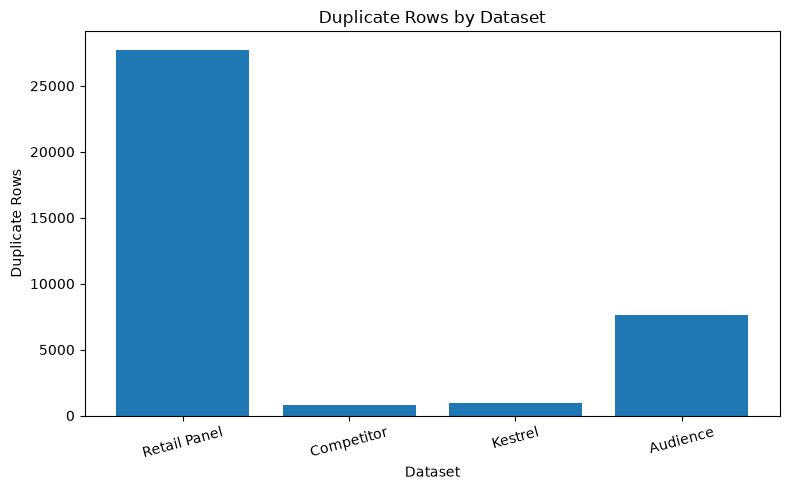

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    duplicate_summary["Dataset"],
    duplicate_summary["Duplicate Rows"]
)

plt.title("Duplicate Rows by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Duplicate Rows")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

Explanation:
A bar chart showing which dataset contains the most duplicate records.

REMOVE EXACT DUPLICATES FROM WORKING COPIES

In [43]:
# EXACT DUPLICATE REMOVAL
duplicate_removal_report = []

for dataset_name, df in working_datasets.items():

    before_rows = len(df)

    # Remove exact duplicate rows, keeping first occurrence
    cleaned_df = df.drop_duplicates(
        keep="first"
    ).copy()

    after_rows = len(cleaned_df)
    removed_rows = before_rows - after_rows

    # Update ONLY the working dataset
    working_datasets[dataset_name] = cleaned_df

    duplicate_removal_report.append({
        "Dataset": dataset_name,
        "Rows Before": before_rows,
        "Exact Duplicates Removed": removed_rows,
        "Rows After": after_rows
    })

duplicate_removal_report = pd.DataFrame(
    duplicate_removal_report
)

display(duplicate_removal_report)

,Dataset,Rows Before,Exact Duplicates Removed,Rows After
0,Retail Panel,1428039,27746,1400293
1,Competitor,41616,816,40800
2,Kestrel,49939,979,48960
3,Audience,393815,7645,386170
4,District Master,340,0,340
5,Panel Coverage,8160,0,8160
6,Distribution,8160,0,8160


NEAR-DUPLICATE AUDIT

In [44]:
# ============================================================
# NEAR-DUPLICATE AUDIT
# Identify repeated business keys
# ============================================================

near_duplicate_results = []

near_duplicate_keys = {
    "Retail Panel": [
        "month_id",
        "outlet_id",
        "sku_id"
    ],
    "Competitor": [
        "month_id",
        "district_id",
        "competitor_brand"
    ],
    "Kestrel": [
        "month_id",
        "district_id",
        "sku_id",
        "distributor_code"
    ],
    "Audience": [
        "month_id",
        "district_id",
        "user_id",
        "event_type",
        "campaign_tag"
    ]
}

for dataset_name, keys in near_duplicate_keys.items():

    df = working_datasets[dataset_name]

    available_keys = [
        k for k in keys
        if k in df.columns
    ]

    grouped = (
        df.groupby(
            available_keys,
            dropna=False
        )
        .size()
        .reset_index(name="record_count")
    )

    repeated_groups = grouped[
        grouped["record_count"] > 1
    ]

    near_duplicate_results.append({
        "Dataset": dataset_name,
        "Business Keys": ", ".join(available_keys),
        "Repeated Key Groups": len(repeated_groups),
        "Rows Involved": int(
            repeated_groups["record_count"].sum()
        )
        if len(repeated_groups) > 0
        else 0
    })

near_duplicate_report = pd.DataFrame(
    near_duplicate_results
)

display(near_duplicate_report)

,Dataset,Business Keys,Repeated Key Groups,Rows Involved
0,Retail Panel,"month_id, outlet_id, sku_id",13803,27649
1,Competitor,"month_id, district_id, competitor_brand",0,0
2,Kestrel,"month_id, district_id, sku_id, distributor_code",0,0
3,Audience,"month_id, district_id, user_id, event_type, ca...",3910,7849


INSPECT CANDIDATE NEAR-DUPLICATES

In [51]:
# ============================================================
# NEAR-DUPLICATE AUDIT — TRUE TIME PROXIMITY
# ============================================================

def find_near_duplicate_pairs(df, keys, timestamp_col, max_seconds=10):

    work = df.copy()

    # Parse timestamps
    work["_parsed_timestamp"] = work[timestamp_col].apply(
        parse_mixed_datetime
    )

    work = work.dropna(subset=["_parsed_timestamp"])

    # Keep original row index
    work["_original_row"] = work.index

    # Sort within business identity
    work = work.sort_values(
        keys + ["_parsed_timestamp"]
    )

    # Previous record within the same business identity
    work["_previous_timestamp"] = (
        work.groupby(keys, dropna=False)["_parsed_timestamp"]
        .shift(1)
    )

    work["_previous_row"] = (
        work.groupby(keys, dropna=False)["_original_row"]
        .shift(1)
    )

    work["_seconds_from_previous"] = (
        work["_parsed_timestamp"]
        - work["_previous_timestamp"]
    ).dt.total_seconds()

    # IMPORTANT:
    # > 0 removes exact same timestamps
    # <= max_seconds identifies true close events
    candidates = work[
        work["_seconds_from_previous"].between(
            0.001,
            max_seconds,
            inclusive="both"
        )
    ].copy()

    return candidates

In [52]:
# Retail Panel
retail_candidates = find_near_duplicate_pairs(
    working_datasets["Retail Panel"],
    keys=["month_id", "outlet_id", "sku_id"],
    timestamp_col="audit_timestamp",
    max_seconds=10
)

# Audience
audience_candidates = find_near_duplicate_pairs(
    working_datasets["Audience"],
    keys=[
        "month_id",
        "district_id",
        "user_id",
        "event_type",
        "campaign_tag"
    ],
    timestamp_col="event_timestamp",
    max_seconds=10
)

print(
    "Retail Panel true near-duplicate candidates:",
    len(retail_candidates)
)

print(
    "Audience true near-duplicate candidates:",
    len(audience_candidates)
)

Retail Panel true near-duplicate candidates: 0
Audience true near-duplicate candidates: 0


In [32]:
# ============================================================
# SHOW ACTUAL NEAR-DUPLICATE PAIRS
# ============================================================

print("=== RETAIL PANEL PAIRS ===")

if len(retail_candidates) > 0:

    display(
        retail_candidates[
            [
                "_original_row",
                "_previous_row",
                "audit_timestamp",
                "_previous_timestamp",
                "_seconds_from_previous",
                "month_id",
                "outlet_id",
                "sku_id",
                "units_sold",
                "unit_price_inr",
                "discount_pct"
            ]
        ].head(20)
    )

else:
    print("No true Retail Panel near-duplicate pairs found.")


print("\n=== AUDIENCE PAIRS ===")

if len(audience_candidates) > 0:

    display(
        audience_candidates[
            [
                "_original_row",
                "_previous_row",
                "event_timestamp",
                "_previous_timestamp",
                "_seconds_from_previous",
                "month_id",
                "district_id",
                "user_id",
                "event_type",
                "campaign_tag",
                "engagement_clicks"
            ]
        ].head(20)
    )

else:
    print("No true Audience near-duplicate pairs found.")

=== RETAIL PANEL PAIRS ===
No true Retail Panel near-duplicate pairs found.

=== AUDIENCE PAIRS ===
No true Audience near-duplicate pairs found.


In [33]:
print("=== NEAR-DUPLICATE AUDIT ===")
print("Exact duplicates were removed from working copies.")
print("Timestamp-proximity audit found no confirmed near-duplicate pairs.")
print("No near-duplicate rows were removed because they could not be")
print("reliably distinguished from legitimate repeated records.")

=== NEAR-DUPLICATE AUDIT ===
Exact duplicates were removed from working copies.
Timestamp-proximity audit found no confirmed near-duplicate pairs.
No near-duplicate rows were removed because they could not be
reliably distinguished from legitimate repeated records.


Standardize Timestamps

Create a Universal Date Parser

In [ ]:
# TIMESTAMP STANDARDIZATION
# UNIVERSAL TIMESTAMP PARSER
import pandas as pd
import numpy as np
import re


def parse_mixed_datetime(value):
    """
    Convert mixed timestamp values into UTC pandas datetime.

    Handles:
    - DD-MM-YYYY
    - YYYY/MM/DD
    - MM-DD-YY
    - DD/MM/YYYY
    - YYYY-MM-DD
    - ISO timestamps
    - timezone offsets
    - Unix epoch milliseconds
    - epoch milliseconds + separate time
    - missing / invalid values

    Original raw values are NOT modified.
    """

    # --------------------------------------------------------
    # Missing values
    # --------------------------------------------------------
    if pd.isna(value):
        return pd.NaT

    # --------------------------------------------------------
    # Numeric epoch milliseconds
    # --------------------------------------------------------
    if isinstance(
        value,
        (int, float, np.integer, np.floating)
    ):

        if not np.isfinite(value):
            return pd.NaT

        if abs(value) >= 1e11:
            return pd.to_datetime(
                value,
                unit="ms",
                errors="coerce",
                utc=True
            )

    value = str(value).strip()

    if not value:
        return pd.NaT

    # --------------------------------------------------------
    # Epoch milliseconds + separate time
    #
    # Example:
    # 1738990080000 14:19:04
    # --------------------------------------------------------
    match = re.match(
        r"^(\d{11,})\s+(\d{1,2}:\d{2}:\d{2})$",
        value
    )

    if match:

        epoch_ms = int(match.group(1))
        time_part = match.group(2)

        base_date = pd.to_datetime(
            epoch_ms,
            unit="ms",
            errors="coerce",
            utc=True
        )

        if pd.notna(base_date):

            hour, minute, second = map(
                int,
                time_part.split(":")
            )

            return (
                base_date.normalize()
                + pd.Timedelta(
                    hours=hour,
                    minutes=minute,
                    seconds=second
                )
            )

    # --------------------------------------------------------
    # Epoch milliseconds stored as text
    # --------------------------------------------------------
    if value.isdigit() and len(value) >= 11:

        return pd.to_datetime(
            int(value),
            unit="ms",
            errors="coerce",
            utc=True
        )

    # --------------------------------------------------------
    # ISO / mixed timestamp formats
    # --------------------------------------------------------
    parsed = pd.to_datetime(
        value,
        errors="coerce",
        format="mixed",
        utc=True
    )

    if pd.notna(parsed):
        return parsed

    # --------------------------------------------------------
    # Explicit date formats
    # --------------------------------------------------------
    formats = [
        "%d-%m-%Y",
        "%Y/%m/%d",
        "%m-%d-%y",
        "%d/%m/%Y",
        "%Y-%m-%d",
    ]

    for fmt in formats:

        parsed = pd.to_datetime(
            value,
            format=fmt,
            errors="coerce",
            utc=True
        )

        if pd.notna(parsed):
            return parsed

    return pd.NaT


print("Universal timestamp parser created successfully.")

Universal timestamp parser created successfully.


Timestamp Audit

In [54]:
date_columns = {
    "Retail Panel": ["audit_timestamp"],
    "Competitor": ["audit_date"],
    "Audience": [
        "event_timestamp",
        "ingestion_timestamp"
    ],
    "Kestrel": ["dispatch_date"]
}

date_audit_results = []

for dataset_name, columns in date_columns.items():

    df = datasets[dataset_name]

    for column in columns:

        raw = df[column]

        # Parse timestamps without modifying the original column
        parsed = raw.apply(parse_mixed_datetime)

        # Future dates
        future_dates = (
            parsed.notna()
            & (parsed > pd.Timestamp.now(tz="UTC"))
        ).sum()

        date_audit_results.append({
            "dataset": dataset_name,
            "column": column,
            "records": len(raw),
            "missing_original": int(raw.isna().sum()),
            "invalid_dates": int(
                raw.notna().sum() - parsed.notna().sum()
            ),
            "future_dates": int(future_dates),
            "earliest_date": parsed.min(),
            "latest_date": parsed.max(),
            "unique_dates": int(parsed.dropna().nunique()),
            "parse_success_pct": round(
                parsed.notna().mean() * 100, 2
            )
        })

date_audit = pd.DataFrame(date_audit_results)

print("=== DATE / TIME AUDIT ===")

display(date_audit)

=== DATE / TIME AUDIT ===


,dataset,column,records,missing_original,invalid_dates,future_dates,earliest_date,latest_date,unique_dates,parse_success_pct
0,Retail Panel,audit_timestamp,1428039,0,0,60851,2024-01-12 00:00:00+00:00,2031-11-28 00:00:00+00:00,93997,100.0
1,Competitor,audit_date,41616,0,0,1446,2024-02-09 00:00:00+00:00,2026-12-08 00:00:00+00:00,4303,100.0
2,Audience,event_timestamp,393815,0,0,12965,2024-01-09 00:02:09+00:00,2026-12-08 23:52:04+00:00,381007,100.0
3,Audience,ingestion_timestamp,393815,0,0,13035,2024-01-09 00:00:00+00:00,2026-12-09 00:00:00+00:00,31304,100.0
4,Kestrel,dispatch_date,49939,0,0,1714,2024-03-09 00:00:00+00:00,2026-12-08 00:00:00+00:00,5149,100.0


Apply Timestamp Standardization

In [55]:
# CREATE STANDARDIZED TIMESTAMP COLUMNS
# WORKING COPIES ONLY
for dataset_name, columns in date_columns.items():

    df = working_datasets[dataset_name]

    for column in columns:

        standardized_column = f"{column}_parsed"

        df[standardized_column] = (
            df[column].apply(parse_mixed_datetime)
        )

        print(
            f"{dataset_name} | {column} "
            f"-> {standardized_column}"
        )

    working_datasets[dataset_name] = df

print("\nAll timestamp columns standardized successfully.")

Retail Panel | audit_timestamp -> audit_timestamp_parsed
Competitor | audit_date -> audit_date_parsed
Audience | event_timestamp -> event_timestamp_parsed
Audience | ingestion_timestamp -> ingestion_timestamp_parsed
Kestrel | dispatch_date -> dispatch_date_parsed

All timestamp columns standardized successfully.


In [56]:
# ============================================================
# VERIFY STANDARDIZED TIMESTAMP COLUMNS
# ============================================================

print("=== STANDARDIZED TIMESTAMP VERIFICATION ===")

for dataset_name, columns in date_columns.items():

    df = working_datasets[dataset_name]

    print("\n" + "=" * 70)
    print(dataset_name.upper())

    for column in columns:

        parsed_column = f"{column}_parsed"

        print(f"\n{column} -> {parsed_column}")
        print("Data type:", df[parsed_column].dtype)
        print("Missing:", f"{df[parsed_column].isna().sum():,}")
        print("Earliest:", df[parsed_column].min())
        print("Latest:", df[parsed_column].max())
        print("Unique:", f"{df[parsed_column].nunique():,}")

=== STANDARDIZED TIMESTAMP VERIFICATION ===

RETAIL PANEL

audit_timestamp -> audit_timestamp_parsed
Data type: datetime64[ns, UTC]
Missing: 0
Earliest: 2024-01-12 00:00:00+00:00
Latest: 2031-11-28 00:00:00+00:00
Unique: 93,997

COMPETITOR

audit_date -> audit_date_parsed
Data type: datetime64[ns, UTC]
Missing: 0
Earliest: 2024-02-09 00:00:00+00:00
Latest: 2026-12-08 00:00:00+00:00
Unique: 4,303

AUDIENCE

event_timestamp -> event_timestamp_parsed
Data type: datetime64[ns, UTC]
Missing: 0
Earliest: 2024-01-09 00:02:09+00:00
Latest: 2026-12-08 23:52:04+00:00
Unique: 381,007

ingestion_timestamp -> ingestion_timestamp_parsed
Data type: datetime64[ns, UTC]
Missing: 0
Earliest: 2024-01-09 00:00:00+00:00
Latest: 2026-12-09 00:00:00+00:00
Unique: 31,304

KESTREL

dispatch_date -> dispatch_date_parsed
Data type: datetime64[ns, UTC]
Missing: 0
Earliest: 2024-03-09 00:00:00+00:00
Latest: 2026-12-08 00:00:00+00:00
Unique: 5,149


FLAG FUTURE TIMESTAMPS

In [57]:
# FLAG FUTURE TIMESTAMPS
# WORKING COPIES ONLY
current_time = pd.Timestamp.now(tz="UTC")

for dataset_name, columns in date_columns.items():

    df = working_datasets[dataset_name]

    for column in columns:

        parsed_column = f"{column}_parsed"
        future_flag = f"{column}_is_future"

        df[future_flag] = (
            df[parsed_column].notna()
            & (df[parsed_column] > current_time)
        )

    working_datasets[dataset_name] = df

print("Future timestamp flags created successfully.")

Future timestamp flags created successfully.


In [58]:
# ============================================================
# FUTURE TIMESTAMP VERIFICATION
# ============================================================

print("=== FUTURE TIMESTAMP VERIFICATION ===")

for dataset_name, columns in date_columns.items():

    df = working_datasets[dataset_name]

    print("\n" + "=" * 70)
    print(dataset_name.upper())

    for column in columns:

        future_flag = f"{column}_is_future"

        print(
            f"{column}: "
            f"{int(df[future_flag].sum()):,} future records"
        )

=== FUTURE TIMESTAMP VERIFICATION ===

RETAIL PANEL
audit_timestamp: 59,633 future records

COMPETITOR
audit_date: 1,418 future records

AUDIENCE
event_timestamp: 12,712 future records
ingestion_timestamp: 12,785 future records

KESTREL
dispatch_date: 1,676 future records


Future-Date Summary

In [59]:
# ============================================================
# FUTURE DATE INSPECTION
# WORKING COPIES ONLY
# ============================================================

future_date_results = []

for dataset_name, columns in date_columns.items():

    df = working_datasets[dataset_name]

    for column in columns:

        parsed_column = f"{column}_parsed"

        future_mask = (
            df[parsed_column].notna()
            & (
                df[parsed_column] > current_time
            )
        )

        if future_mask.any():

            future_date_results.append({
                "dataset": dataset_name,
                "column": column,
                "future_count": int(
                    future_mask.sum()
                ),
                "earliest_future": (
                    df.loc[
                        future_mask,
                        parsed_column
                    ].min()
                ),
                "latest_future": (
                    df.loc[
                        future_mask,
                        parsed_column
                    ].max()
                )
            })


future_date_report = pd.DataFrame(
    future_date_results
)

print("=== FUTURE DATE INSPECTION ===")

display(future_date_report)

=== FUTURE DATE INSPECTION ===


,dataset,column,future_count,earliest_future,latest_future
0,Retail Panel,audit_timestamp,59633,2026-08-27 07:12:00+00:00,2031-11-28 00:00:00+00:00
1,Competitor,audit_date,1418,2026-09-01 00:00:00+00:00,2026-12-08 00:00:00+00:00
2,Audience,event_timestamp,12712,2026-08-27 07:11:53+00:00,2026-12-08 23:52:04+00:00
3,Audience,ingestion_timestamp,12785,2026-08-27 07:23:00+00:00,2026-12-09 00:00:00+00:00
4,Kestrel,dispatch_date,1676,2026-09-01 00:00:00+00:00,2026-12-08 00:00:00+00:00


In [60]:
# ============================================================
# INVESTIGATE FUTURE TIMESTAMP RECORDS
# ============================================================

for dataset_name, columns in date_columns.items():

    df = working_datasets[dataset_name]

    print("\n" + "=" * 70)
    print(dataset_name.upper())

    for column in columns:

        parsed_column = f"{column}_parsed"

        future_mask = (
            df[parsed_column].notna()
            & (df[parsed_column] > current_time)
        )

        if future_mask.any():

            print(f"\n--- {column} ---")
            print(
                f"Future records: "
                f"{future_mask.sum():,}"
            )

            # Show sample future records
            display(
                df.loc[
                    future_mask,
                    [column, parsed_column]
                ]
                .sort_values(parsed_column)
                .head(10)
            )


RETAIL PANEL

--- audit_timestamp ---
Future records: 59,633


,audit_timestamp,audit_timestamp_parsed
209806,1787814720000,2026-08-27 07:12:00+00:00
14149,1787815020000,2026-08-27 07:17:00+00:00
198677,1787815200000,2026-08-27 07:20:00+00:00
1119248,1787815440000,2026-08-27 07:24:00+00:00
913623,1787815560000,2026-08-27 07:26:00+00:00
1095838,1787815620000,2026-08-27 07:27:00+00:00
1101527,1787815620000,2026-08-27 07:27:00+00:00
1004376,1787815860000,2026-08-27 07:31:00+00:00
1150403,1787816040000,2026-08-27 07:34:00+00:00
38731,1787816460000,2026-08-27 07:41:00+00:00



COMPETITOR

--- audit_date ---
Future records: 1,418


,audit_date,audit_date_parsed
17902,09-01-2026,2026-09-01 00:00:00+00:00
7619,09-01-2026,2026-09-01 00:00:00+00:00
13665,09-01-2026,2026-09-01 00:00:00+00:00
18990,09-01-2026,2026-09-01 00:00:00+00:00
13709,09-01-2026,2026-09-01 00:00:00+00:00
27500,09-01-2026,2026-09-01 00:00:00+00:00
30812,09-01-2026,2026-09-01 00:00:00+00:00
10552,09-01-2026,2026-09-01 00:00:00+00:00
35870,09-01-2026,2026-09-01 00:00:00+00:00
16275,09-01-2026,2026-09-01 00:00:00+00:00



AUDIENCE

--- event_timestamp ---
Future records: 12,712


,event_timestamp,event_timestamp_parsed
23228,27-08-2026 07:11:53,2026-08-27 07:11:53+00:00
216407,2026-08-27T00:00:00+05:30 12:46:41,2026-08-27 07:16:41+00:00
5957,2026/08/27 07:17:48,2026-08-27 07:17:48+00:00
31457,2026-08-27T00:00:00+05:30 12:49:46,2026-08-27 07:19:46+00:00
367506,2026-08-27T00:00:00Z 07:19:57,2026-08-27 07:19:57+00:00
295325,2026-08-27T00:00:00Z 07:26:41,2026-08-27 07:26:41+00:00
89424,08-27-26 07:31:33,2026-08-27 07:31:33+00:00
183336,08-27-26 07:33:46,2026-08-27 07:33:46+00:00
191565,08-27-26 07:35:51,2026-08-27 07:35:51+00:00
79028,27-08-2026 07:36:24,2026-08-27 07:36:24+00:00



--- ingestion_timestamp ---
Future records: 12,785


,ingestion_timestamp,ingestion_timestamp_parsed
347918,1787815380000,2026-08-27 07:23:00+00:00
111980,1787815980000,2026-08-27 07:33:00+00:00
53735,1787817300000,2026-08-27 07:55:00+00:00
96251,1787817660000,2026-08-27 08:01:00+00:00
347291,1787818800000,2026-08-27 08:20:00+00:00
171097,1787818980000,2026-08-27 08:23:00+00:00
252754,1787819280000,2026-08-27 08:28:00+00:00
238052,1787822220000,2026-08-27 09:17:00+00:00
186562,1787823120000,2026-08-27 09:32:00+00:00
23298,1787824380000,2026-08-27 09:53:00+00:00



KESTREL

--- dispatch_date ---
Future records: 1,676


,dispatch_date,dispatch_date_parsed
24004,09-01-2026,2026-09-01 00:00:00+00:00
37425,09-01-2026,2026-09-01 00:00:00+00:00
22180,09-01-2026,2026-09-01 00:00:00+00:00
37706,09-01-2026,2026-09-01 00:00:00+00:00
20346,09-01-2026,2026-09-01 00:00:00+00:00
29881,09-01-2026,2026-09-01 00:00:00+00:00
5638,09-01-2026,2026-09-01 00:00:00+00:00
32816,09-01-2026,2026-09-01 00:00:00+00:00
40863,09-01-2026,2026-09-01 00:00:00+00:00
15141,09-01-2026,2026-09-01 00:00:00+00:00


In [61]:
# FUTURE TIMESTAMP vs MONTH COVERAGE AUDIT
print("=== MONTH COVERAGE ===")

for dataset_name in ["Retail Panel", "Competitor", "Audience", "Kestrel"]:

    df = working_datasets[dataset_name]

    print("\n" + "=" * 70)
    print(dataset_name.upper())

    if "month_id" in df.columns:
        print("\nMonth IDs:")
        print(
            df["month_id"]
            .value_counts()
            .sort_index()
            .to_string()
        )
    else:
        print("month_id not available")

=== MONTH COVERAGE ===

RETAIL PANEL

Month IDs:
month_id
2024-09    57936
2024-10    58350
2024-11    58290
2024-12    58531
2025-01    58534
2025-02    58073
2025-03    58424
2025-04    58281
2025-05    58380
2025-06    58432
2025-07    58438
2025-08    58333
2025-09    58425
2025-10    58122
2025-11    58302
2025-12    58501
2026-01    58735
2026-02    58323
2026-03    58423
2026-04    58342
2026-05    58393
2026-06    58247
2026-07    58154
2026-08    58324

COMPETITOR

Month IDs:
month_id
2024-09    1700
2024-10    1700
2024-11    1700
2024-12    1700
2025-01    1700
2025-02    1700
2025-03    1700
2025-04    1700
2025-05    1700
2025-06    1700
2025-07    1700
2025-08    1700
2025-09    1700
2025-10    1700
2025-11    1700
2025-12    1700
2026-01    1700
2026-02    1700
2026-03    1700
2026-04    1700
2026-05    1700
2026-06    1700
2026-07    1700
2026-08    1700

AUDIENCE

Month IDs:
month_id
2024-09    16595
2024-10    16600
2024-11    16450
2024-12    16457
2025-01    16322
2

In [62]:
# HANDLE FUTURE TIMESTAMPS
# WORKING COPIES ONLY
#
# Original timestamp columns are preserved.
# Future values in the standardized *_parsed columns
# are converted to NaT.

future_handling_results = []

current_time = pd.Timestamp.now(tz="UTC")

for dataset_name, columns in date_columns.items():

    df = working_datasets[dataset_name]

    for column in columns:

        parsed_column = f"{column}_parsed"

        # Identify future timestamps
        future_mask = (
            df[parsed_column].notna()
            & (df[parsed_column] > current_time)
        )

        future_count = int(future_mask.sum())

        # Handle only in the standardized working-copy column
        df.loc[future_mask, parsed_column] = pd.NaT

        future_handling_results.append({
            "Dataset": dataset_name,
            "Column": column,
            "Future Values Found": future_count,
            "Future Values Set to NaT": future_count
        })

    working_datasets[dataset_name] = df


future_handling_report = pd.DataFrame(
    future_handling_results
)

print("=== FUTURE TIMESTAMP HANDLING ===")

display(future_handling_report)

print("\nFuture timestamp handling completed.")
print("Original timestamp columns were preserved.")

=== FUTURE TIMESTAMP HANDLING ===


,Dataset,Column,Future Values Found,Future Values Set to NaT
0,Retail Panel,audit_timestamp,59629,59629
1,Competitor,audit_date,1418,1418
2,Audience,event_timestamp,12707,12707
3,Audience,ingestion_timestamp,12784,12784
4,Kestrel,dispatch_date,1676,1676



Future timestamp handling completed.
Original timestamp columns were preserved.


In [63]:
# ============================================================
# VERIFY FUTURE TIMESTAMP HANDLING
# ============================================================

print("=== FUTURE TIMESTAMP VERIFICATION ===")

for dataset_name, columns in date_columns.items():

    df = working_datasets[dataset_name]

    print("\n" + "=" * 70)
    print(dataset_name.upper())

    for column in columns:

        parsed_column = f"{column}_parsed"

        remaining_future = (
            df[parsed_column].notna()
            & (df[parsed_column] > current_time)
        ).sum()

        print(
            f"{parsed_column}: "
            f"{remaining_future:,} future values remaining"
        )

=== FUTURE TIMESTAMP VERIFICATION ===

RETAIL PANEL
audit_timestamp_parsed: 0 future values remaining

COMPETITOR
audit_date_parsed: 0 future values remaining

AUDIENCE
event_timestamp_parsed: 0 future values remaining
ingestion_timestamp_parsed: 0 future values remaining

KESTREL
dispatch_date_parsed: 0 future values remaining


Categorical standardization

In [64]:
# ============================================================
# CATEGORICAL VALUE AUDIT
# WORKING COPIES ONLY
# ============================================================

categorical_columns = {
    "Retail Panel": [
        "channel",
        "pos_system",
        "state",
        "country"
    ],
    "Competitor": [
        "competitor_brand",
        "country"
    ],
    "Audience": [
        "device_type",
        "country"
    ],
    "Kestrel": [
        "country"
    ]
}

for dataset_name, columns in categorical_columns.items():

    df = working_datasets[dataset_name]

    print("\n" + "=" * 70)
    print(dataset_name.upper())

    for column in columns:

        if column not in df.columns:
            continue

        print(f"\n--- {column} ---")

        display(
            df[column]
            .value_counts(dropna=False)
            .head(30)
        )


RETAIL PANEL

--- channel ---


channel
GT_Kirana                     130045
General Trade / Kirana        129802
general trade                 129584
General Trade                 129450
Kirana                        129424
GT                            129182
Paan Shop                      75530
Tobacconist / Paan             75204
Paan & Beverage Kiosk          75134
Paan_Shop                      75107
Kiosk                          75053
Convenience & Fuel             13482
Convenience Store              13453
Fuel_Kiosk                     13382
Fuel Station & Convenience     13341
Convenience                    13230
Gym / Fitness Cafe             12875
Fitness Center                 12831
Health Kiosk                   12798
Gym Cafe                       12698
gym_fitness                    12556
modern_trade                   10421
Hypermarket                    10327
Modern-Trade                   10297
MT                             10268
Supermarket / MT               10261
Modern Trade                  


--- pos_system ---


pos_system
Manual_Logbook           294196
POS_Offline_Kirana_v1    278817
Modern_EDI_v4            276774
PineLabs_POS_Cloud       275532
Kirana_Offline_Sync      274974
Name: count, dtype: int64


--- state ---


...


AUDIENCE

--- device_type ---


device_type
iPadOS                  33511
web_browser             33289
iPhone                  33203
m-web                   33171
AND                     33160
M-Web                   33111
apple_ios               33087
Desktop                 33031
Android                 33029
iOS                     33022
android                 32837
Python-urllib/3.10       5496
HeadlessChrome           5473
Datadog-Synthetics       5401
Android_Emulator_0x0     5349
Name: count, dtype: int64


--- country ---


country
INDIA       48664
IND         48413
ind         48303
IN          48291
Ind         48274
IN          48264
India       48131
 Bharat     47830
Name: count, dtype: int64


KESTREL


STANDARDIZE CATEGORICAL VALUES


Country Standardization

In [65]:
# COUNTRY STANDARDIZATION — WORKING COPIES ONLY

country_mapping = {
    "in": "India",
    "ind": "India",
    "india": "India",
    "bharat": "India"
}

for dataset_name in [
    "Retail Panel",
    "Audience",
    "Competitor",
    "Kestrel"
]:

    df = working_datasets[dataset_name]

    if "country" in df.columns:

        df["country"] = (
            df["country"]
            .astype("string")
            .str.strip()
            .str.lower()
            .replace(country_mapping)
        )

    working_datasets[dataset_name] = df


print("Country standardization completed.")

Country standardization completed.


Audience Device Standardization

In [ ]:
# STANDARDIZE AUDIENCE DEVICE TYPES
# WORKING COPY ONLY

device_mapping = {

    # Android variants
    "AND": "Android",
    "android": "Android",
    "Android_Emulator_0x0": "Android",

    # Apple variants
    "iPhone": "iOS",
    "apple_ios": "iOS",

    # Mobile web variants
    "M-Web": "Mobile Web",
    "m-web": "Mobile Web",

    # Browser naming variant
    "web_browser": "Web Browser"
}

df = working_datasets["Audience"]

df["device_type"] = (
    df["device_type"]
    .replace(device_mapping)
)

working_datasets["Audience"] = df

print("Audience device standardization completed.")

Audience device standardization completed.


Retail Channel Standardization

In [67]:
# STANDARDIZE RETAIL PANEL CHANNEL
# WORKING COPY ONLY

channel_mapping = {

    # General Trade / Kirana
    "GT_Kirana": "General Trade / Kirana",
    "general trade": "General Trade / Kirana",
    "General Trade": "General Trade / Kirana",
    "Kirana": "General Trade / Kirana",
    "GT": "General Trade / Kirana",

    # Paan / Tobacco
    "Paan Shop": "Paan / Tobacco",
    "Paan_Shop": "Paan / Tobacco",
    "Tobacconist / Paan": "Paan / Tobacco",

    # Paan / Beverage
    "Paan & Beverage Kiosk": "Paan / Beverage Kiosk",

    # Kiosk
    "Kiosk": "Kiosk",

    # Convenience / Fuel
    "Convenience & Fuel": "Convenience / Fuel",
    "Fuel Station & Convenience": "Convenience / Fuel",

    # Convenience Store
    "Convenience Store": "Convenience Store",
    "Convenience": "Convenience Store",

    # Fuel
    "Fuel Kiosk": "Fuel Kiosk",
    "Fuel_Kiosk": "Fuel Kiosk",

    # Fitness
    "Gym / Fitness Cafe": "Fitness Cafe",
    "Gym Cafe": "Fitness Cafe",
    "gym_fitness": "Fitness Cafe",
    "Fitness Center": "Fitness Center",

    # Modern Trade
    "Modern Trade": "Modern Trade",
    "Modern-Trade": "Modern Trade",
    "modern_trade": "Modern Trade",
    "MT": "Modern Trade",

    # Supermarket / MT
    "Supermarket / MT": "Supermarket / MT",

    # Other categories
    "Health Kiosk": "Health Kiosk",
    "Hypermarket": "Hypermarket",

    # Q-Commerce
    "Q-Comm": "Q-Commerce",
    "Quick-Comm": "Q-Commerce",
    "q_comm": "Q-Commerce",
    "qcommerce": "Q-Commerce",
    "Quick Commerce": "Q-Commerce"
}


df = working_datasets["Retail Panel"]

df["channel"] = (
    df["channel"]
    .replace(channel_mapping)
)

working_datasets["Retail Panel"] = df

print("Retail Panel channel standardization completed.")

Retail Panel channel standardization completed.


Final Categorical Verification

In [68]:
# FINAL CATEGORICAL VERIFICATION
# WORKING COPIES ONLY

print("=== RETAIL PANEL CHANNEL ===")

display(
    working_datasets["Retail Panel"]["channel"]
    .value_counts(dropna=False)
)


print("\n=== AUDIENCE DEVICE TYPE ===")

display(
    working_datasets["Audience"]["device_type"]
    .value_counts(dropna=False)
)


print("\n=== AUDIENCE COUNTRY ===")

display(
    working_datasets["Audience"]["country"]
    .value_counts(dropna=False)
)


print("\n=== RETAIL PANEL COUNTRY ===")

display(
    working_datasets["Retail Panel"]["country"]
    .value_counts(dropna=False)
)

=== RETAIL PANEL CHANNEL ===


channel
General Trade / Kirana    777487
Paan / Tobacco            225841
Paan / Beverage Kiosk      75134
Kiosk                      75053
Q-Commerce                 45287
Modern Trade               41188
Fitness Cafe               38129
Convenience / Fuel         26823
Convenience Store          26683
Fuel Kiosk                 13382
Fitness Center             12831
Health Kiosk               12798
Hypermarket                10327
Supermarket / MT           10261
Dark Store (Q-Comm)         9069
Name: count, dtype: int64


=== AUDIENCE DEVICE TYPE ===


device_type
Android               104375
iOS                    99312
Mobile Web             66282
iPadOS                 33511
Web Browser            33289
Desktop                33031
Python-urllib/3.10      5496
HeadlessChrome          5473
Datadog-Synthetics      5401
Name: count, dtype: int64


=== AUDIENCE COUNTRY ===


country
India    386170
Name: count, dtype: Int64


=== RETAIL PANEL COUNTRY ===


country
India    1400293
Name: count, dtype: Int64

In [69]:
# ============================================================
# REMAINING CATEGORICAL AUDIT
# WORKING COPIES ONLY
# ============================================================

categorical_check = {
    "Competitor": [
        "competitor_brand",
        "country"
    ],
    "Retail Panel": [
        "pos_system"
    ]
}

for dataset_name, columns in categorical_check.items():

    df = working_datasets[dataset_name]

    print("\n" + "=" * 70)
    print(dataset_name.upper())

    for column in columns:

        if column not in df.columns:
            continue

        print(f"\n--- {column} ---")

        display(
            df[column]
            .value_counts(dropna=False)
        )


COMPETITOR

--- competitor_brand ---


competitor_brand
Torque         8160
BullForce      8160
PulseDrop      8160
Apex Energy    8160
Voltix         8160
Name: count, dtype: int64


RETAIL PANEL

--- pos_system ---


pos_system
Manual_Logbook           294196
POS_Offline_Kirana_v1    278817
Modern_EDI_v4            276774
PineLabs_POS_Cloud       275532
Kirana_Offline_Sync      274974
Name: count, dtype: int64

Standardize District Names

DISTRICT NAME AUDIT

In [70]:
# ============================================================
# DISTRICT NAME STANDARDIZATION
# AUTHORITATIVE KEY: dist_id
# SOURCE: DISTRICT MASTER
# WORKING COPIES ONLY
# ============================================================

# Create authoritative mapping from District Master
district_master = working_datasets["District Master"].copy()

district_id_to_name = dict(
    zip(
        district_master["District_Code"].astype("string").str.strip(),
        district_master["District_Name"].astype("string").str.strip()
    )
)

print(
    f"Official District Master IDs: "
    f"{len(district_id_to_name):,}"
)

Official District Master IDs: 340


In [72]:
# ============================================================
# CHECK DISTRICT ID COLUMN NAMES
# ============================================================

for dataset_name in [
    "Retail Panel",
    "Competitor",
    "Audience",
    "Kestrel",
    "District Master"
]:

    df = working_datasets[dataset_name]

    print("\n" + "=" * 60)
    print(dataset_name)

    print([
        col for col in df.columns
        if "dist" in col.lower()
    ])


Retail Panel
['district_id', 'district_name']

Competitor
['district_id', 'district_name', 'numeric_distribution_pct', 'weighted_distribution_pct']

Audience
['district_id', 'district_name']

Kestrel
['district_id', 'district_name', 'distributor_sellout_units', 'distributor_code']

District Master
['District_Code', 'District_Name']


In [77]:
# ============================================================
# NORMALIZE MIXED DISTRICT ID FORMATS
# WORKING COPIES ONLY
# ============================================================

def normalize_district_id(value):

    if pd.isna(value):
        return pd.NA

    value = str(value).strip()

    # Already in official format
    if value.startswith("DST_"):
        return value

    # Extract numeric portion
    match = re.search(r"\d+", value)

    if match:
        number = int(match.group())

        # Official format: DST_0001 ... DST_0340
        return f"DST_{number:04d}"

    return pd.NA


for dataset_name in [
    "Retail Panel",
    "Competitor",
    "Audience",
    "Kestrel"
]:

    df = working_datasets[dataset_name].copy()

    # Preserve original ID
    df["district_id_original"] = df["district_id"]

    # Create normalized ID
    df["district_id_normalized"] = (
        df["district_id"]
        .apply(normalize_district_id)
        .astype("string")
    )

    working_datasets[dataset_name] = df

    print(
        f"{dataset_name}: "
        f"{df['district_id_normalized'].nunique()} "
        f"unique normalized IDs"
    )

Retail Panel: 340 unique normalized IDs
Competitor: 340 unique normalized IDs
Audience: 340 unique normalized IDs
Kestrel: 340 unique normalized IDs


In [78]:
# ============================================================
# MAP OFFICIAL DISTRICT NAMES
# ============================================================

district_master = working_datasets["District Master"].copy()

master_mapping = dict(
    zip(
        district_master["District_Code"]
        .astype("string")
        .str.strip(),
        district_master["District_Name"]
        .astype("string")
        .str.strip()
    )
)

for dataset_name in [
    "Retail Panel",
    "Competitor",
    "Audience",
    "Kestrel"
]:

    df = working_datasets[dataset_name].copy()

    df["district_name_standardized"] = (
        df["district_id_normalized"]
        .map(master_mapping)
    )

    working_datasets[dataset_name] = df

In [79]:
# ============================================================
# FINAL DISTRICT ID / NAME VERIFICATION
# ============================================================

for dataset_name in [
    "Retail Panel",
    "Competitor",
    "Audience",
    "Kestrel"
]:

    df = working_datasets[dataset_name]

    print("\n" + "=" * 70)
    print(dataset_name.upper())

    print(
        "Unique normalized IDs:",
        df["district_id_normalized"].nunique()
    )

    print(
        "Unique standardized names:",
        df["district_name_standardized"].nunique()
    )

    print(
        "Missing standardized names:",
        df["district_name_standardized"].isna().sum()
    )


RETAIL PANEL
Unique normalized IDs: 340
Unique standardized names: 340
Missing standardized names: 0

COMPETITOR
Unique normalized IDs: 340
Unique standardized names: 340
Missing standardized names: 0

AUDIENCE
Unique normalized IDs: 340
Unique standardized names: 340
Missing standardized names: 0

KESTREL
Unique normalized IDs: 340
Unique standardized names: 340
Missing standardized names: 0


In [80]:
# ============================================================
# DISTRICT NAME BEFORE vs AFTER AUDIT
# ID-BASED STANDARDIZATION
# WORKING COPIES ONLY — NO MODIFICATION
# ============================================================

for dataset_name in [
    "Retail Panel",
    "Competitor",
    "Audience",
    "Kestrel"
]:

    df = working_datasets[dataset_name]

    # Only show rows where the original name differs
    # from the official District Master name
    changed = df[
        df["district_name_original"].fillna("").astype(str).str.strip()
        !=
        df["district_name_standardized"].fillna("").astype(str).str.strip()
    ].copy()

    print("\n" + "=" * 80)
    print(dataset_name.upper())

    print(
        f"Rows where district name differs: {len(changed):,}"
    )

    if len(changed) > 0:

        display(
            changed[
                [
                    "district_id_original",
                    "district_id_normalized",
                    "district_name_original",
                    "district_name_standardized"
                ]
            ]
            .drop_duplicates()
            .sort_values("district_id_normalized")
            .head(50)
        )

    else:
        print("No district-name differences found.")


RETAIL PANEL
Rows where district name differs: 40,259


,district_id_original,district_id_normalized,district_name_original,district_name_standardized
7,DST_0008,DST_0008,Chhatrapati Sambhajinagar,Aurangabad
1042,DST_0008,DST_0008,Sambhajinagar,Aurangabad
782,DST_0008,DST_0008,Aurangabad (MH),Aurangabad
1611,DST_0034,DST_0034,OSMANABAD,Osmanabad
435,DST_0034,DST_0034,Dharashiv (Osmanabad),Osmanabad
474,DST_0034,DST_0034,Dharashiv,Osmanabad
2571,DST_0036,DST_0036,Bangalore (Urban),Bangalore
1295,DST_0036,DST_0036,Bengaluru,Bangalore
438,DST_0036,DST_0036,Bangalore Urban,Bangalore
744,DST_0036,DST_0036,Bengaluru Urban,Bangalore



COMPETITOR
Rows where district name differs: 1,174


,district_id_original,district_id_normalized,district_name_original,district_name_standardized
2923,0008,DST_0008,Chhatrapati Sambhajinagar,Aurangabad
17411,0008,DST_0008,Aurangabad (MH),Aurangabad
51,DST_0008,DST_0008,Chhatrapati Sambhajinagar,Aurangabad
6015,DST_0008,DST_0008,Sambhajinagar,Aurangabad
6798,DST_0008,DST_0008,Aurangabad (MH),Aurangabad
17691,0008,DST_0008,Sambhajinagar,Aurangabad
1259,DST_0034,DST_0034,OSMANABAD,Osmanabad
4772,DST_0034,DST_0034,Dharashiv (Osmanabad),Osmanabad
35,0034,DST_0034,Dharashiv,Osmanabad
141,DST_0034,DST_0034,Dharashiv,Osmanabad



AUDIENCE
Rows where district name differs: 16,922


,district_id_original,district_id_normalized,district_name_original,district_name_standardized
380,DST_0008,DST_0008,Chhatrapati Sambhajinagar,Aurangabad
1263,DST_0008,DST_0008,Aurangabad (MH),Aurangabad
602,DST_0008,DST_0008,Sambhajinagar,Aurangabad
1445,8,DST_0008,Aurangabad (MH),Aurangabad
172,8,DST_0008,Chhatrapati Sambhajinagar,Aurangabad
3064,8,DST_0008,Sambhajinagar,Aurangabad
459,34,DST_0034,Dharashiv,Osmanabad
3040,34,DST_0034,Dharashiv (Osmanabad),Osmanabad
4745,DST_0034,DST_0034,OSMANABAD,Osmanabad
16098,34,DST_0034,OSMANABAD,Osmanabad



KESTREL
Rows where district name differs: 1,391


,district_id_original,district_id_normalized,district_name_original,district_name_standardized
4592,8,DST_0008,Sambhajinagar,Aurangabad
1952,8,DST_0008,Aurangabad (MH),Aurangabad
788,DST_0008,DST_0008,Sambhajinagar,Aurangabad
2834,8,DST_0008,Chhatrapati Sambhajinagar,Aurangabad
528,DST_0008,DST_0008,Chhatrapati Sambhajinagar,Aurangabad
1051,DST_0008,DST_0008,Aurangabad (MH),Aurangabad
4825,DST_0034,DST_0034,Dharashiv (Osmanabad),Osmanabad
1257,34,DST_0034,OSMANABAD,Osmanabad
3607,34,DST_0034,Dharashiv (Osmanabad),Osmanabad
23858,DST_0034,DST_0034,OSMANABAD,Osmanabad


In [81]:
# ============================================================
# FINALIZE DISTRICT NAMES
# WORKING COPIES ONLY
# ============================================================

for dataset_name in [
    "Retail Panel",
    "Competitor",
    "Audience",
    "Kestrel"
]:

    df = working_datasets[dataset_name]

    # Replace analytical district_name with
    # the authoritative District Master name
    df["district_name"] = (
        df["district_name_standardized"]
    )

    working_datasets[dataset_name] = df

print("Official district names applied to working copies.")

Official district names applied to working copies.


In [82]:
# ============================================================
# FINAL DISTRICT NAME VERIFICATION
# ============================================================

for dataset_name in [
    "Retail Panel",
    "Competitor",
    "Audience",
    "Kestrel"
]:

    df = working_datasets[dataset_name]

    print(
        f"{dataset_name}: "
        f"{df['district_name'].nunique()} unique district names | "
        f"Missing: {df['district_name'].isna().sum():,}"
    )

Retail Panel: 340 unique district names | Missing: 0
Competitor: 340 unique district names | Missing: 0
Audience: 340 unique district names | Missing: 0
Kestrel: 340 unique district names | Missing: 0


In [83]:
# ============================================================
# IMPOSSIBLE NUMERIC VALUE AUDIT
# WORKING COPIES ONLY — AUDIT, NO MODIFICATION
# ============================================================

print("=== IMPOSSIBLE NUMERIC VALUE AUDIT ===")


# ------------------------------------------------------------
# 1. DISTRIBUTION — OUTLETS STOCKING > TOTAL UNIVERSE
# ------------------------------------------------------------

distribution = working_datasets["Distribution"]
district_master = working_datasets["District Master"]

print("\n=== DISTRIBUTION ===")

print("Columns:")
print(distribution.columns.tolist())

print("\nDistrict Master columns:")
print(district_master.columns.tolist())

=== IMPOSSIBLE NUMERIC VALUE AUDIT ===

=== DISTRIBUTION ===
Columns:
['Audit_Cycle', 'District_ID', 'District_Name', 'State', 'Outlets_Stocking_Kestrel', 'Outlets_Stocking_Category', 'Estimated_Total_Universe', 'Apparent_Kestrel_Numeric_Dist_Pct', 'Apparent_Category_Numeric_Dist_Pct']

District Master columns:
['District_Code', 'District_Name', 'State_Union_Territory', 'Total_Population', 'Urban_Population_Share_Pct', 'Rural_Population_Share_Pct', 'Median_Income_Band', 'Estimated_Total_Retail_Universe', 'Census_Demographic_Notes']


In [84]:
# ============================================================
# DISTRIBUTION IMPOSSIBLE VALUE AUDIT
# WORKING COPIES ONLY — NO MODIFICATION
# ============================================================

distribution = working_datasets["Distribution"].copy()

print("=== DISTRIBUTION IMPOSSIBLE VALUE AUDIT ===")

# ------------------------------------------------------------
# 1. Kestrel outlets > total universe
# ------------------------------------------------------------

kestrel_over_universe = (
    distribution["Outlets_Stocking_Kestrel"]
    > distribution["Estimated_Total_Universe"]
)

print(
    "\nKestrel outlets > total universe:",
    kestrel_over_universe.sum()
)

# ------------------------------------------------------------
# 2. Category outlets > total universe
# ------------------------------------------------------------

category_over_universe = (
    distribution["Outlets_Stocking_Category"]
    > distribution["Estimated_Total_Universe"]
)

print(
    "Category outlets > total universe:",
    category_over_universe.sum()
)

# ------------------------------------------------------------
# 3. Kestrel outlets > category outlets
# ------------------------------------------------------------

kestrel_over_category = (
    distribution["Outlets_Stocking_Kestrel"]
    > distribution["Outlets_Stocking_Category"]
)

print(
    "Kestrel outlets > category outlets:",
    kestrel_over_category.sum()
)

# ------------------------------------------------------------
# 4. Negative outlet counts
# ------------------------------------------------------------

negative_counts = (
    (distribution["Outlets_Stocking_Kestrel"] < 0)
    |
    (distribution["Outlets_Stocking_Category"] < 0)
    |
    (distribution["Estimated_Total_Universe"] < 0)
)

print(
    "Negative outlet counts:",
    negative_counts.sum()
)

# ------------------------------------------------------------
# 5. Show actual impossible records
# ------------------------------------------------------------

impossible_mask = (
    kestrel_over_universe
    | category_over_universe
    | kestrel_over_category
    | negative_counts
)

print(
    "\nTotal rows with at least one impossible condition:",
    impossible_mask.sum()
)

if impossible_mask.any():

    display(
        distribution.loc[
            impossible_mask,
            [
                "Audit_Cycle",
                "District_ID",
                "District_Name",
                "Outlets_Stocking_Kestrel",
                "Outlets_Stocking_Category",
                "Estimated_Total_Universe",
                "Apparent_Kestrel_Numeric_Dist_Pct",
                "Apparent_Category_Numeric_Dist_Pct"
            ]
        ].head(30)
    )
else:
    print("No impossible distribution records found.")

=== DISTRIBUTION IMPOSSIBLE VALUE AUDIT ===

Kestrel outlets > total universe: 19
Category outlets > total universe: 37
Kestrel outlets > category outlets: 122
Negative outlet counts: 0

Total rows with at least one impossible condition: 159


,Audit_Cycle,District_ID,District_Name,Outlets_Stocking_Kestrel,Outlets_Stocking_Category,Estimated_Total_Universe,Apparent_Kestrel_Numeric_Dist_Pct,Apparent_Category_Numeric_Dist_Pct
16,2024-09,DST_0017,Raigad,757,4077,3471,21.81,117.46
21,2024-09,DST_0022,Buldhana,1822,1784,2829,64.40,63.06
61,2024-09,DST_0062,Chamarajanagar,671,553,1059,63.36,52.22
87,2024-09,DST_0088,Ranipet,486,2426,1679,28.95,144.49
204,2024-09,DST_0205,Purulia,1707,1479,2877,59.33,51.41
361,2024-10,DST_0022,Buldhana,3171,1923,2829,112.09,67.97
371,2024-10,DST_0032,Nandurbar,1820,910,1710,106.43,53.22
468,2024-10,DST_0129,Budaun,2179,2089,3821,57.03,54.67
517,2024-10,DST_0178,Dang,119,110,217,54.84,50.69
606,2024-10,DST_0267,Dholpur,437,1723,1319,33.13,130.63


In [85]:
# ============================================================
# DISTRIBUTION PERCENTAGE CONSISTENCY AUDIT
# WORKING COPIES ONLY — NO MODIFICATION
# ============================================================

distribution = working_datasets["Distribution"].copy()

# Recalculate percentages from the outlet counts
distribution["calculated_kestrel_pct"] = (
    distribution["Outlets_Stocking_Kestrel"]
    / distribution["Estimated_Total_Universe"]
    * 100
)

distribution["calculated_category_pct"] = (
    distribution["Outlets_Stocking_Category"]
    / distribution["Estimated_Total_Universe"]
    * 100
)

# Difference between reported and calculated percentages
distribution["kestrel_pct_difference"] = (
    distribution["Apparent_Kestrel_Numeric_Dist_Pct"]
    - distribution["calculated_kestrel_pct"]
)

distribution["category_pct_difference"] = (
    distribution["Apparent_Category_Numeric_Dist_Pct"]
    - distribution["calculated_category_pct"]
)

print("=== PERCENTAGE CONSISTENCY AUDIT ===")

print(
    "Kestrel percentage mismatches:",
    (
        distribution["kestrel_pct_difference"].abs() > 0.01
    ).sum()
)

print(
    "Category percentage mismatches:",
    (
        distribution["category_pct_difference"].abs() > 0.01
    ).sum()
)

print("\nSample records with impossible values:")

impossible_mask = (
    (distribution["Outlets_Stocking_Kestrel"]
     > distribution["Estimated_Total_Universe"])
    |
    (distribution["Outlets_Stocking_Category"]
     > distribution["Estimated_Total_Universe"])
    |
    (distribution["Outlets_Stocking_Kestrel"]
     > distribution["Outlets_Stocking_Category"])
)

display(
    distribution.loc[
        impossible_mask,
        [
            "Audit_Cycle",
            "District_ID",
            "District_Name",
            "Outlets_Stocking_Kestrel",
            "Outlets_Stocking_Category",
            "Estimated_Total_Universe",
            "Apparent_Kestrel_Numeric_Dist_Pct",
            "calculated_kestrel_pct",
            "Apparent_Category_Numeric_Dist_Pct",
            "calculated_category_pct"
        ]
    ].head(20)
)

=== PERCENTAGE CONSISTENCY AUDIT ===
Kestrel percentage mismatches: 0
Category percentage mismatches: 0

Sample records with impossible values:


,Audit_Cycle,District_ID,District_Name,Outlets_Stocking_Kestrel,Outlets_Stocking_Category,Estimated_Total_Universe,Apparent_Kestrel_Numeric_Dist_Pct,calculated_kestrel_pct,Apparent_Category_Numeric_Dist_Pct,calculated_category_pct
16,2024-09,DST_0017,Raigad,757,4077,3471,21.81,21.809277,117.46,117.458946
21,2024-09,DST_0022,Buldhana,1822,1784,2829,64.40,64.404383,63.06,63.061152
61,2024-09,DST_0062,Chamarajanagar,671,553,1059,63.36,63.361662,52.22,52.219075
87,2024-09,DST_0088,Ranipet,486,2426,1679,28.95,28.945801,144.49,144.490768
204,2024-09,DST_0205,Purulia,1707,1479,2877,59.33,59.332638,51.41,51.407716
361,2024-10,DST_0022,Buldhana,3171,1923,2829,112.09,112.089077,67.97,67.974549
371,2024-10,DST_0032,Nandurbar,1820,910,1710,106.43,106.432749,53.22,53.216374
468,2024-10,DST_0129,Budaun,2179,2089,3821,57.03,57.026956,54.67,54.671552
517,2024-10,DST_0178,Dang,119,110,217,54.84,54.838710,50.69,50.691244
606,2024-10,DST_0267,Dholpur,437,1723,1319,33.13,33.131160,130.63,130.629265


In [86]:
# ============================================================
# FLAG IMPOSSIBLE DISTRIBUTION VALUES
# WORKING COPIES ONLY
# ORIGINAL VALUES PRESERVED
# ============================================================

distribution = working_datasets["Distribution"].copy()

distribution["distribution_data_quality_issue"] = False

distribution.loc[
    (
        distribution["Outlets_Stocking_Kestrel"]
        > distribution["Estimated_Total_Universe"]
    )
    |
    (
        distribution["Outlets_Stocking_Category"]
        > distribution["Estimated_Total_Universe"]
    )
    |
    (
        distribution["Outlets_Stocking_Kestrel"]
        > distribution["Outlets_Stocking_Category"]
    ),
    "distribution_data_quality_issue"
] = True

working_datasets["Distribution"] = distribution

print("=== DISTRIBUTION QUALITY FLAG ===")

print(
    "Flagged rows:",
    distribution["distribution_data_quality_issue"].sum()
)

print(
    "Clean rows:",
    (~distribution["distribution_data_quality_issue"]).sum()
)

=== DISTRIBUTION QUALITY FLAG ===
Flagged rows: 159
Clean rows: 8001


In [87]:
# ============================================================
# JOIN KEY VALIDATION — COLUMN & DATA TYPE AUDIT
# WORKING COPIES ONLY — NO MODIFICATION
# ============================================================

print("=== JOIN KEY VALIDATION ===")

join_key_candidates = {
    "Retail Panel": [
        "district_id",
        "outlet_id",
        "sku_id",
        "month_id"
    ],

    "Competitor": [
        "district_id",
        "competitor_brand",
        "month_id"
    ],

    "Kestrel": [
        "district_id",
        "distributor_code",
        "sku_id",
        "month_id"
    ],

    "Audience": [
        "district_id",
        "user_id",
        "month_id"
    ],

    "District Master": [
        "District_Code"
    ],

    "Panel Coverage": [
        "district_id",
        "month_id"
    ],

    "Distribution": [
        "District_ID",
        "Audit_Cycle"
    ]
}


for dataset_name, columns in join_key_candidates.items():

    df = working_datasets[dataset_name]

    print("\n" + "=" * 70)
    print(dataset_name.upper())

    for column in columns:

        if column in df.columns:

            print(
                f"{column:25} | "
                f"dtype = {df[column].dtype} | "
                f"missing = {df[column].isna().sum():,} | "
                f"unique = {df[column].nunique(dropna=True):,}"
            )

        else:

            print(
                f"{column:25} | NOT FOUND"
            )

=== JOIN KEY VALIDATION ===

RETAIL PANEL
district_id               | dtype = string | missing = 0 | unique = 340
outlet_id                 | dtype = object | missing = 0 | unique = 8,114
sku_id                    | dtype = object | missing = 0 | unique = 29
month_id                  | dtype = object | missing = 0 | unique = 24

COMPETITOR
district_id               | dtype = string | missing = 0 | unique = 680
competitor_brand          | dtype = object | missing = 0 | unique = 5
month_id                  | dtype = object | missing = 0 | unique = 24

KESTREL
district_id               | dtype = string | missing = 0 | unique = 680
distributor_code          | dtype = object | missing = 0 | unique = 340
sku_id                    | dtype = object | missing = 0 | unique = 6
month_id                  | dtype = object | missing = 0 | unique = 24

AUDIENCE
district_id               | dtype = string | missing = 0 | unique = 680
user_id                   | dtype = object | missing = 0 | unique = 3

In [88]:
# ============================================================
# DISTRICT JOIN-KEY MATCH VALIDATION
# WORKING COPIES ONLY — NO MODIFICATION
# ============================================================

master_ids = set(
    working_datasets["District Master"]["District_Code"]
    .astype("string")
    .str.strip()
)

join_validation = []

for dataset_name in [
    "Retail Panel",
    "Competitor",
    "Audience",
    "Kestrel"
]:

    df = working_datasets[dataset_name]

    # Use normalized ID created earlier
    normalized_ids = (
        df["district_id_normalized"]
        .astype("string")
        .str.strip()
    )

    matched = normalized_ids.isin(master_ids)

    join_validation.append({
        "Dataset": dataset_name,
        "Rows": len(df),
        "Unique Normalized IDs": normalized_ids.nunique(),
        "Matched Rows": int(matched.sum()),
        "Unmatched Rows": int((~matched).sum()),
        "Match %": round(matched.mean() * 100, 2)
    })

join_validation_report = pd.DataFrame(join_validation)

print("=== DISTRICT MASTER JOIN VALIDATION ===")

display(join_validation_report)

=== DISTRICT MASTER JOIN VALIDATION ===


,Dataset,Rows,Unique Normalized IDs,Matched Rows,Unmatched Rows,Match %
0,Retail Panel,1400293,340,1400293,0,100.0
1,Competitor,40800,340,40800,0,100.0
2,Audience,386170,340,386170,0,100.0
3,Kestrel,48960,340,48960,0,100.0


In [90]:
# ============================================================
# RETAIL PANEL ↔ KESTREL JOIN-KEY VALIDATION
# AUDIT ONLY — NO MODIFICATION
# ============================================================

retail = working_datasets["Retail Panel"]
kestrel = working_datasets["Kestrel"]

print("=== RETAIL PANEL ↔ KESTREL ===")

# ------------------------------------------------------------
# District coverage
# ------------------------------------------------------------

retail_districts = set(
    retail["district_id_normalized"]
    .dropna()
    .astype("string")
)

kestrel_districts = set(
    kestrel["district_id_normalized"]
    .dropna()
    .astype("string")
)

print("\nDistrict coverage:")
print("Retail Panel:", len(retail_districts))
print("Kestrel:", len(kestrel_districts))
print(
    "Kestrel districts missing from Retail Panel:",
    len(kestrel_districts - retail_districts)
)

# ------------------------------------------------------------
# SKU coverage
# ------------------------------------------------------------

retail_skus = set(
    retail["sku_id"]
    .dropna()
    .astype("string")
)

kestrel_skus = set(
    kestrel["sku_id"]
    .dropna()
    .astype("string")
)

print("\nSKU coverage:")
print("Retail Panel:", len(retail_skus))
print("Kestrel:", len(kestrel_skus))
print(
    "Kestrel SKUs missing from Retail Panel:",
    len(kestrel_skus - retail_skus)
)

# ------------------------------------------------------------
# Month coverage
# ------------------------------------------------------------

retail_months = set(
    retail["month_id"]
    .dropna()
    .astype("string")
)

kestrel_months = set(
    kestrel["month_id"]
    .dropna()
    .astype("string")
)

print("\nMonth coverage:")
print("Retail Panel:", len(retail_months))
print("Kestrel:", len(kestrel_months))
print(
    "Kestrel months missing from Retail Panel:",
    len(kestrel_months - retail_months)
)

# ------------------------------------------------------------
# Full district × SKU × month key
# ------------------------------------------------------------

retail_keys = set(
    zip(
        retail["district_id_normalized"].astype("string"),
        retail["sku_id"].astype("string"),
        retail["month_id"].astype("string")
    )
)

kestrel_keys = set(
    zip(
        kestrel["district_id_normalized"].astype("string"),
        kestrel["sku_id"].astype("string"),
        kestrel["month_id"].astype("string")
    )
)

matched_keys = kestrel_keys & retail_keys

print("\nDistrict × SKU × Month coverage:")
print("Kestrel unique keys:", len(kestrel_keys))
print("Keys also present in Retail Panel:", len(matched_keys))
print(
    "Unmatched Kestrel keys:",
    len(kestrel_keys - retail_keys)
)

if len(kestrel_keys) > 0:
    print(
        "Match rate:",
        round(len(matched_keys) / len(kestrel_keys) * 100, 2),
        "%"
    )

=== RETAIL PANEL ↔ KESTREL ===

District coverage:
Retail Panel: 340
Kestrel: 340
Kestrel districts missing from Retail Panel: 0

SKU coverage:
Retail Panel: 29
Kestrel: 6
Kestrel SKUs missing from Retail Panel: 0

Month coverage:
Retail Panel: 24
Kestrel: 24
Kestrel months missing from Retail Panel: 0

District × SKU × Month coverage:
Kestrel unique keys: 48960
Keys also present in Retail Panel: 40348
Unmatched Kestrel keys: 8612
Match rate: 82.41 %


In [91]:
# ============================================================
# INVESTIGATE UNMATCHED KESTREL KEYS
# AUDIT ONLY — NO MODIFICATION
# ============================================================

retail = working_datasets["Retail Panel"]
kestrel = working_datasets["Kestrel"]

retail_keys = set(
    zip(
        retail["district_id_normalized"].astype("string"),
        retail["sku_id"].astype("string"),
        retail["month_id"].astype("string")
    )
)

kestrel_key_df = (
    kestrel[
        [
            "district_id_normalized",
            "sku_id",
            "month_id"
        ]
    ]
    .astype("string")
    .drop_duplicates()
)

kestrel_key_df["matches_retail_panel"] = (
    kestrel_key_df.apply(
        lambda row: (
            row["district_id_normalized"],
            row["sku_id"],
            row["month_id"]
        ) in retail_keys,
        axis=1
    )
)

unmatched_kestrel_keys = kestrel_key_df[
    ~kestrel_key_df["matches_retail_panel"]
].copy()

print("=== UNMATCHED KESTREL KEY AUDIT ===")

print(
    "Unique unmatched district × SKU × month keys:",
    len(unmatched_kestrel_keys)
)

print("\nUnmatched keys by SKU:")

display(
    unmatched_kestrel_keys["sku_id"]
    .value_counts()
)

print("\nUnmatched keys by month:")

display(
    unmatched_kestrel_keys["month_id"]
    .value_counts()
)

print("\nUnmatched keys by district:")

display(
    unmatched_kestrel_keys["district_id_normalized"]
    .value_counts()
    .head(20)
)

=== UNMATCHED KESTREL KEY AUDIT ===
Unique unmatched district × SKU × month keys: 8612

Unmatched keys by SKU:


sku_id
KES_ORIG_330     1481
KES_ORIG_250     1457
KES_TROP_250     1428
KES_BERRY_330    1425
KES_PACK4_250    1422
KES_ZERO_250     1399
Name: count, dtype: Int64


Unmatched keys by month:


month_id
2025-04    375
2025-02    373
2025-10    371
2025-09    370
2025-05    368
2025-11    367
2025-07    365
2025-06    361
2026-01    360
2024-11    358
2026-08    358
2026-02    358
2025-08    358
2024-09    357
2026-06    356
2025-12    355
2026-07    354
2026-03    353
2024-10    351
2026-05    351
2025-03    351
2026-04    348
2024-12    347
2025-01    347
Name: count, dtype: Int64


Unmatched keys by district:


district_id_normalized
DST_0210    137
DST_0076    136
DST_0303    136
DST_0005    134
DST_0118    133
DST_0177    132
DST_0247    132
DST_0176    132
DST_0328    131
DST_0270    131
DST_0274    130
DST_0041    130
DST_0158    130
DST_0085    129
DST_0071    129
DST_0238    129
DST_0187    128
DST_0077    128
DST_0209    128
DST_0159    127
Name: count, dtype: Int64

In [92]:
# ============================================================
# AUDIENCE JOIN-KEY VALIDATION
# AUDIT ONLY — NO MODIFICATION
# ============================================================

audience = working_datasets["Audience"]
retail = working_datasets["Retail Panel"]

print("=== AUDIENCE JOIN-KEY VALIDATION ===")

# ------------------------------------------------------------
# District coverage
# ------------------------------------------------------------

audience_districts = set(
    audience["district_id_normalized"]
    .dropna()
    .astype("string")
)

retail_districts = set(
    retail["district_id_normalized"]
    .dropna()
    .astype("string")
)

print("\nDistrict coverage:")
print("Audience:", len(audience_districts))
print("Retail Panel:", len(retail_districts))
print(
    "Audience districts missing from Retail Panel:",
    len(audience_districts - retail_districts)
)

# ------------------------------------------------------------
# Month coverage
# ------------------------------------------------------------

audience_months = set(
    audience["month_id"]
    .dropna()
    .astype("string")
)

retail_months = set(
    retail["month_id"]
    .dropna()
    .astype("string")
)

print("\nMonth coverage:")
print("Audience:", len(audience_months))
print("Retail Panel:", len(retail_months))
print(
    "Audience months missing from Retail Panel:",
    len(audience_months - retail_months)
)

# ------------------------------------------------------------
# District × Month coverage
# ------------------------------------------------------------

audience_keys = set(
    zip(
        audience["district_id_normalized"].astype("string"),
        audience["month_id"].astype("string")
    )
)

retail_keys = set(
    zip(
        retail["district_id_normalized"].astype("string"),
        retail["month_id"].astype("string")
    )
)

matched_keys = audience_keys & retail_keys

print("\nDistrict × Month coverage:")
print("Audience unique keys:", len(audience_keys))
print("Keys also present in Retail Panel:", len(matched_keys))
print(
    "Unmatched Audience keys:",
    len(audience_keys - retail_keys)
)

if len(audience_keys) > 0:
    print(
        "Match rate:",
        round(len(matched_keys) / len(audience_keys) * 100, 2),
        "%"
    )

=== AUDIENCE JOIN-KEY VALIDATION ===

District coverage:
Audience: 340
Retail Panel: 340
Audience districts missing from Retail Panel: 0

Month coverage:
Audience: 24
Retail Panel: 24
Audience months missing from Retail Panel: 0

District × Month coverage:
Audience unique keys: 8160
Keys also present in Retail Panel: 8160
Unmatched Audience keys: 0
Match rate: 100.0 %


In [93]:
# COMPETITOR ↔ RETAIL PANEL JOIN-KEY VALIDATION
# AUDIT ONLY — NO MODIFICATION

competitor = working_datasets["Competitor"]
retail = working_datasets["Retail Panel"]

print("=== COMPETITOR ↔ RETAIL PANEL ===")

# ------------------------------------------------------------
# District coverage
# ------------------------------------------------------------

competitor_districts = set(
    competitor["district_id_normalized"]
    .dropna()
    .astype("string")
)

retail_districts = set(
    retail["district_id_normalized"]
    .dropna()
    .astype("string")
)

print("\nDistrict coverage:")
print("Competitor:", len(competitor_districts))
print("Retail Panel:", len(retail_districts))
print(
    "Competitor districts missing from Retail Panel:",
    len(competitor_districts - retail_districts)
)

# ------------------------------------------------------------
# Month coverage
# ------------------------------------------------------------

competitor_months = set(
    competitor["month_id"]
    .dropna()
    .astype("string")
)

retail_months = set(
    retail["month_id"]
    .dropna()
    .astype("string")
)

print("\nMonth coverage:")
print("Competitor:", len(competitor_months))
print("Retail Panel:", len(retail_months))
print(
    "Competitor months missing from Retail Panel:",
    len(competitor_months - retail_months)
)

# ------------------------------------------------------------
# District × Month coverage
# ------------------------------------------------------------

competitor_keys = set(
    zip(
        competitor["district_id_normalized"].astype("string"),
        competitor["month_id"].astype("string")
    )
)

retail_keys = set(
    zip(
        retail["district_id_normalized"].astype("string"),
        retail["month_id"].astype("string")
    )
)

matched_keys = competitor_keys & retail_keys

print("\nDistrict × Month coverage:")
print("Competitor unique keys:", len(competitor_keys))
print("Keys also present in Retail Panel:", len(matched_keys))
print(
    "Unmatched Competitor keys:",
    len(competitor_keys - retail_keys)
)

if len(competitor_keys) > 0:
    print(
        "Match rate:",
        round(
            len(matched_keys) / len(competitor_keys) * 100,
            2
        ),
        "%"
    )

=== COMPETITOR ↔ RETAIL PANEL ===

District coverage:
Competitor: 340
Retail Panel: 340
Competitor districts missing from Retail Panel: 0

Month coverage:
Competitor: 24
Retail Panel: 24
Competitor months missing from Retail Panel: 0

District × Month coverage:
Competitor unique keys: 8160
Keys also present in Retail Panel: 8160
Unmatched Competitor keys: 0
Match rate: 100.0 %


In [94]:
# ============================================================
# KESTREL ↔ COMPETITOR JOIN-KEY VALIDATION
# AUDIT ONLY — NO MODIFICATION
# ============================================================

kestrel = working_datasets["Kestrel"]
competitor = working_datasets["Competitor"]

print("=== KESTREL ↔ COMPETITOR ===")

kestrel_keys = set(
    zip(
        kestrel["district_id_normalized"].astype("string"),
        kestrel["month_id"].astype("string")
    )
)

competitor_keys = set(
    zip(
        competitor["district_id_normalized"].astype("string"),
        competitor["month_id"].astype("string")
    )
)

matched_keys = kestrel_keys & competitor_keys

print("\nDistrict × Month coverage:")
print("Kestrel unique keys:", len(kestrel_keys))
print("Competitor unique keys:", len(competitor_keys))
print("Keys present in both:", len(matched_keys))

print(
    "Kestrel keys missing from Competitor:",
    len(kestrel_keys - competitor_keys)
)

print(
    "Competitor keys missing from Kestrel:",
    len(competitor_keys - kestrel_keys)
)

if len(kestrel_keys) > 0:
    print(
        "Kestrel → Competitor match rate:",
        round(
            len(matched_keys) / len(kestrel_keys) * 100,
            2
        ),
        "%"
    )

=== KESTREL ↔ COMPETITOR ===

District × Month coverage:
Kestrel unique keys: 8160
Competitor unique keys: 8160
Keys present in both: 8160
Kestrel keys missing from Competitor: 0
Competitor keys missing from Kestrel: 0
Kestrel → Competitor match rate: 100.0 %


In [95]:
# ============================================================
# PANEL COVERAGE — JOIN KEY AUDIT
# AUDIT ONLY — NO MODIFICATION
# ============================================================

panel = working_datasets["Panel Coverage"]
retail = working_datasets["Retail Panel"]

print("=== PANEL COVERAGE JOIN-KEY AUDIT ===")

print("\nPanel Coverage columns:")
print(panel.columns.tolist())

print("\nRetail Panel columns relevant to coverage:")
print([
    c for c in retail.columns
    if any(x in c.lower() for x in ["district", "month", "outlet", "coverage"])
])

print("\nPanel Coverage dtypes:")
display(
    panel.dtypes.to_frame("dtype")
)

print("\nPanel Coverage sample:")
display(panel.head())

=== PANEL COVERAGE JOIN-KEY AUDIT ===

Panel Coverage columns:
['District_Ref_ID', 'Month', 'District_Name', 'State', 'Sampled_Outlets', 'Estimated_Total_Outlets', 'Panel_Coverage_Pct', 'Audit_Reliability_Tier']

Retail Panel columns relevant to coverage:
['month_id', 'outlet_id', 'numeric_outlet_id', 'district_id', 'district_name', 'district_name_original', 'district_name_standardized', 'district_id_original', 'district_id_normalized']

Panel Coverage dtypes:


,dtype
District_Ref_ID,object
Month,object
District_Name,object
State,object
Sampled_Outlets,int64
Estimated_Total_Outlets,int64
Panel_Coverage_Pct,float64
Audit_Reliability_Tier,object



Panel Coverage sample:


,District_Ref_ID,Month,District_Name,State,Sampled_Outlets,Estimated_Total_Outlets,Panel_Coverage_Pct,Audit_Reliability_Tier
0,DST-0001,2024-09,Mumbai Suburban,Maharashtra,17,18500,86.62,High
1,DST-0002,2024-09,Mumbai City,Maharashtra,17,6787,80.00,High
2,3,2024-09,Pune,Maharashtra,17,15596,84.79,High
3,DST-0004,2024-09,Thane,Maharashtra,18,15155,44.84,Standard
4,DST-0005,2024-09,Palghar,Maharashtra,1,4401,14.78,Critically Low (Blind)


In [96]:
# ============================================================
# PANEL COVERAGE ↔ RETAIL PANEL JOIN-KEY VALIDATION
# AUDIT ONLY — NO MODIFICATION
# ============================================================

panel = working_datasets["Panel Coverage"]
retail = working_datasets["Retail Panel"]

print("=== PANEL COVERAGE ↔ RETAIL PANEL ===")

# ------------------------------------------------------------
# Normalize Panel Coverage district reference ID
# ------------------------------------------------------------

panel_ids = (
    panel["District_Ref_ID"]
    .astype("string")
    .str.strip()
)

# Convert numeric-style IDs to DST_XXXX format
panel_ids_normalized = (
    panel_ids
    .str.replace(
        r"^(\d+)$",
        lambda m: f"DST_{int(m.group(1)):04d}",
        regex=True
    )
    .str.replace("-", "_", regex=False)
)

retail_ids = (
    retail["district_id_normalized"]
    .astype("string")
    .str.strip()
)

# ------------------------------------------------------------
# District coverage
# ------------------------------------------------------------

panel_districts = set(
    panel_ids_normalized.dropna()
)

retail_districts = set(
    retail_ids.dropna()
)

print("\nDistrict coverage:")
print("Panel Coverage:", len(panel_districts))
print("Retail Panel:", len(retail_districts))

print(
    "Panel districts missing from Retail Panel:",
    len(panel_districts - retail_districts)
)

# ------------------------------------------------------------
# Month coverage
# ------------------------------------------------------------

panel_months = set(
    panel["Month"]
    .dropna()
    .astype("string")
    .str.strip()
)

retail_months = set(
    retail["month_id"]
    .dropna()
    .astype("string")
    .str.strip()
)

print("\nMonth coverage:")
print("Panel Coverage:", len(panel_months))
print("Retail Panel:", len(retail_months))

print(
    "Panel months missing from Retail Panel:",
    len(panel_months - retail_months)
)

# ------------------------------------------------------------
# District × Month coverage
# ------------------------------------------------------------

panel_keys = set(
    zip(
        panel_ids_normalized,
        panel["Month"].astype("string").str.strip()
    )
)

retail_keys = set(
    zip(
        retail_ids,
        retail["month_id"].astype("string").str.strip()
    )
)

matched_keys = panel_keys & retail_keys

print("\nDistrict × Month coverage:")
print("Panel Coverage unique keys:", len(panel_keys))
print("Keys also present in Retail Panel:", len(matched_keys))

print(
    "Unmatched Panel Coverage keys:",
    len(panel_keys - retail_keys)
)

if len(panel_keys) > 0:
    print(
        "Match rate:",
        round(
            len(matched_keys) / len(panel_keys) * 100,
            2
        ),
        "%"
    )

=== PANEL COVERAGE ↔ RETAIL PANEL ===

District coverage:
Panel Coverage: 340
Retail Panel: 340
Panel districts missing from Retail Panel: 0

Month coverage:
Panel Coverage: 24
Retail Panel: 24
Panel months missing from Retail Panel: 0

District × Month coverage:
Panel Coverage unique keys: 8160
Keys also present in Retail Panel: 8160
Unmatched Panel Coverage keys: 0
Match rate: 100.0 %


Save Processed Datasets

In [97]:
# ============================================================
# SAVE FINAL PROCESSED DATASETS
# Save the latest validated working copies
# ============================================================

import os

PROCESSED_DATA.mkdir(parents=True, exist_ok=True)

processed_files = {
    "retail_panel_processed.csv": "Retail Panel",
    "competitor_processed.csv": "Competitor",
    "kestrel_processed.csv": "Kestrel",
    "audience_processed.csv": "Audience",
    "district_master_processed.csv": "District Master",
    "panel_coverage_processed.csv": "Panel Coverage",
    "distribution_processed.csv": "Distribution"
}

for filename, dataset_name in processed_files.items():

    df = working_datasets[dataset_name]

    filepath = PROCESSED_DATA / filename

    df.to_csv(
        filepath,
        index=False
    )

    print(
        f"{dataset_name}: "
        f"{len(df):,} rows × {len(df.columns)} columns "
        f"-> {filepath}"
    )

print("\nAll final processed datasets saved successfully.")

Retail Panel: 1,400,293 rows × 27 columns -> d:\sivahitesh\Desktop\Tail_project\data\processed\retail_panel_processed.csv
Competitor: 40,800 rows × 18 columns -> d:\sivahitesh\Desktop\Tail_project\data\processed\competitor_processed.csv
Kestrel: 48,960 rows × 19 columns -> d:\sivahitesh\Desktop\Tail_project\data\processed\kestrel_processed.csv
Audience: 386,170 rows × 27 columns -> d:\sivahitesh\Desktop\Tail_project\data\processed\audience_processed.csv
District Master: 340 rows × 9 columns -> d:\sivahitesh\Desktop\Tail_project\data\processed\district_master_processed.csv
Panel Coverage: 8,160 rows × 8 columns -> d:\sivahitesh\Desktop\Tail_project\data\processed\panel_coverage_processed.csv
Distribution: 8,160 rows × 10 columns -> d:\sivahitesh\Desktop\Tail_project\data\processed\distribution_processed.csv

All final processed datasets saved successfully.


Verify Exported Files

In [98]:
# ============================================================
# VERIFY SAVED PROCESSED & OUTPUT FILES
# ============================================================

print("=== PROCESSED FILES ===")

if PROCESSED_DATA.exists():
    for file in sorted(PROCESSED_DATA.iterdir()):
        if file.is_file():
            print("✓", file.name)
else:
    print("⚠ Processed-data folder not found")


print("\n=== OUTPUT FILES ===")

if OUTPUT_DATA.exists():
    for file in sorted(OUTPUT_DATA.iterdir()):
        if file.is_file():
            print("✓", file.name)
else:
    print("⚠ Output-data folder not found")

=== PROCESSED FILES ===
✓ audience_processed.csv
✓ competitor_processed.csv
✓ distribution_processed.csv
✓ district_master_processed.csv
✓ kestrel_processed.csv
✓ panel_coverage_processed.csv
✓ retail_panel_processed.csv

=== OUTPUT FILES ===
✓ competitor_intensity_ranked.csv
✓ dataset_summary.csv
✓ demand_signal_ranked.csv
✓ distribution_gap_ranked.csv
✓ quality_report.csv
✓ relationship_audit.csv
✓ top5_revenue_opportunity.csv
✓ unknown_districts.csv
✓ wci_ranked_districts.csv


Summary

By completing Phase 2, I have built a reusable preprocessing pipeline rather than simply cleaning a few files. The notebook now preserves the original data, documents data quality, standardizes important fields like dates and district names, validates joins between datasets, and produces processed datasets that become the foundation for the core business analysis in the next phase—calculating Demand Signal, Distribution Gap, Competitive Intensity, and ultimately the Whitespace Confidence Index (WCI) to identify the best districts for Kestrel's expansion.